In [59]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [60]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [61]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [62]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [63]:
################################################################################

In [64]:
#DATA DESCRIPTIONS

### Data Type
# MicroPulse Differential Absorption Lidar (MPD)

### DOI (Permanent Link)
# https://doi.org/10.26023/50Z5-ZHXE-7B0D

### Summary
# MicroPulse Differential Absorption Lidar (MPD) data 
# in NetCDF format which were collected during the 
# Prediction of Rainfall Extremes Campaign In the Pacific (PRECIP). 
# Three MPDs were deployed to Taiwan for this field project.

### Temporal Coverage
# Begin datetime 2022-05-28 00:00:00
# End datetime 2022-08-22 23:59:59

### Spatial Coverage
# Maximum (North) Latitude: 24.97, Minimum (South) Latitude: 24.76
# Minimum (West) Longitude: 121.01, Maximum (East) Longitude: 121.76

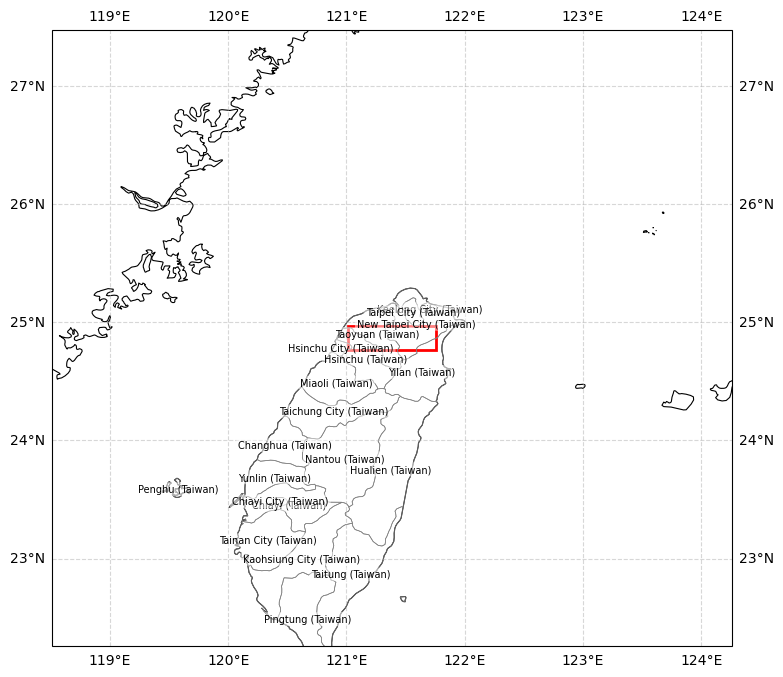

In [65]:
mapPlotting = MapPlotting(
    sw_corner=(24.76, 121.01),  # (lat_min, lon_min)
    ne_corner=(24.97, 121.76),  # (lat_max, lon_max)
    delta=2.5,
    fontsize=7
)
mapPlotting.PlotBoundingBox()

In [66]:
################################################################################

In [67]:
#SET UP DIRECTORIES
Campaign="PRECIP"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

#Data Directory
DataType="PRECIP_NCAR_MPD_Data"
Observation_Data_Directory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
Data_Directory1 = os.path.join(Observation_Data_Directory,Campaign,DataType,"unzip","MPD_02")
print("Data Directory Set as:", Data_Directory1, '\n')
FileList1 = ListFiles(Data_Directory1)

Data_Directory2 = os.path.join(Observation_Data_Directory,Campaign,DataType,"unzip","MPD_03")
print("Data Directory Set as:", Data_Directory2, '\n')
FileList2 = ListFiles(Data_Directory2)

Data_Directory3 = os.path.join(Observation_Data_Directory,Campaign,DataType,"unzip","MPD_04")
print("Data Directory Set as:", Data_Directory3, '\n')
FileList3 = ListFiles(Data_Directory3)

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP 

Data Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_02 

Listing first 10 files:
 ['mpd02.20220626.Python.nc', 'mpd02.20220703.Python.nc', 'mpd02.20220727.Python.nc', 'mpd02.20220729.Python.nc', 'mpd02.20220802.Python.nc', 'mpd02.20220618.Python.nc', 'mpd02.20220530.Python.nc', 'mpd02.20220719.Python.nc', 'mpd02.20220614.Python.nc', 'mpd02.20220627.Python.nc'] 

Data Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_NCAR_MPD_Data/unzip/MPD_03 

Listing first 10 files:
 ['mpd03.20220710.Python.nc', 'mpd03.20220812.Python.nc', 'mpd03.20220613.Python.nc', 'mpd03.20220610.Python.nc', 'mpd03.20220802.Python.nc', 'mpd03.20220529.Python.nc', 'mpd03.20220616.Python.nc', 'mpd03.20220528.Python.nc', 'mpd03.20220721.P

In [68]:
#READING DATA
###################################

In [168]:
def GetData(index):
    DataFile = os.path.join(Data_Directory,FileList1[index])
    DataNC = xr.open_dataset(DataFile)
    return DataNC

In [177]:
index=2
DataNC = GetData(index=index)
# DataNC.data_vars

In [178]:
#PLOTTING FUNCTIONS
###################################

In [179]:
import numpy as np

def QuickPlot_tz(ax, DataNC, varName, rangeSlice=None):
    da = DataNC[varName]

    if rangeSlice is not None:
        # If user gave a slice of physical values
        if isinstance(rangeSlice, slice):
            coords = DataNC['range'].values

            # Handle start
            if rangeSlice.start is not None:
                start_idx = np.abs(coords - rangeSlice.start).argmin()
            else:
                start_idx = None

            # Handle stop
            if rangeSlice.stop is not None:
                stop_idx = np.abs(coords - rangeSlice.stop).argmin()
            else:
                stop_idx = None

            # Construct index slice
            da = da.isel(range=slice(start_idx, stop_idx))
        else:
            # If scalar, just pick nearest value
            da = da.sel(range=rangeSlice, method="nearest")

    da.T.plot(ax=ax, add_colorbar=True)
    ax.set_title(varName)
    ax.set_ylim(bottom=0)


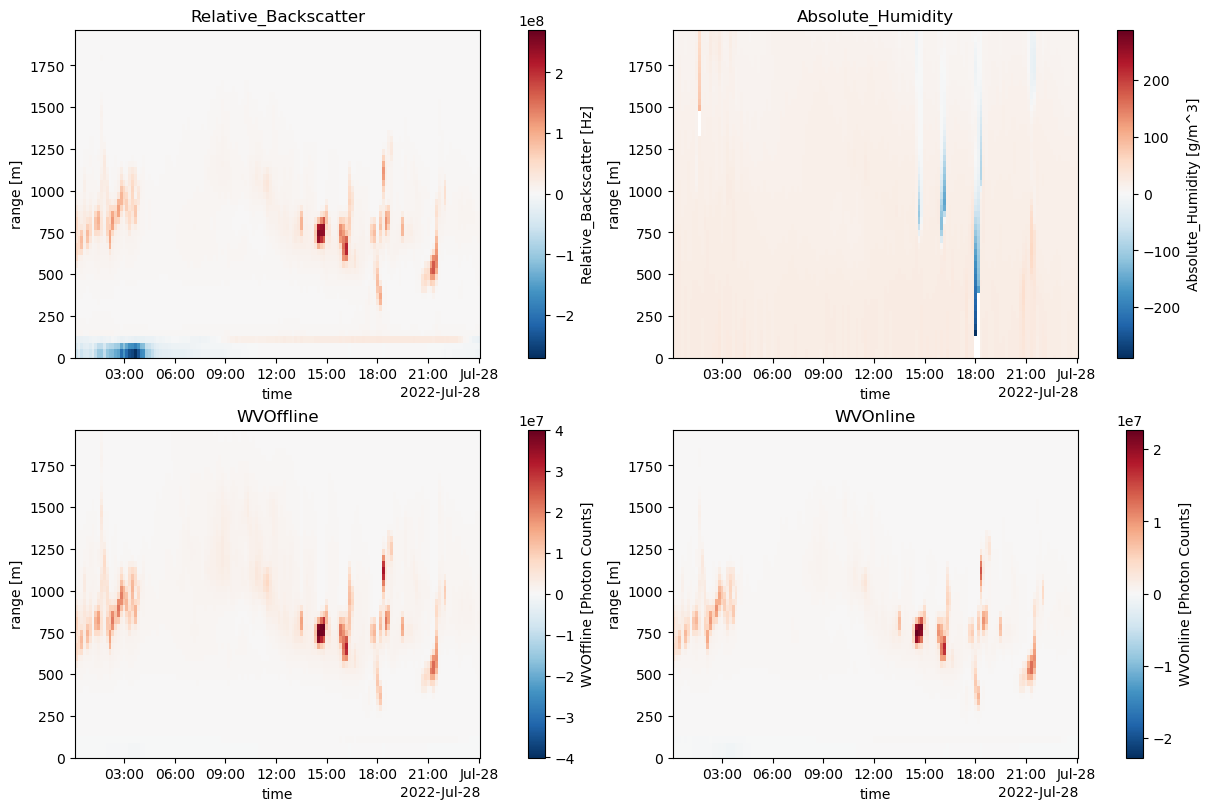

In [180]:
# --- Variables to plot ---
vars_to_plot = [
    "Relative_Backscatter",
    "Absolute_Humidity",
    "WVOffline",
    "WVOnline"
]

# --- Figure with GridSpec (2 rows, 2 cols) ---
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)

# --- Create subplots using GridSpec ---
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]

# --- Fill with plots ---
for ax, var in zip(axes, vars_to_plot):
    QuickPlot_tz(ax, DataNC, var, rangeSlice=slice(0,2000))
